In [1]:
import uproot
import hist
import matplotlib.pyplot as plt
import mplhep as hep
import numpy as np
from matplotlib.lines import Line2D
import ROOT
plt.style.use(hep.styles.CMS)

In [18]:
histos_dy_v1p2 = uproot.open("histograms/histograms_dy_v1p2.root")
histos_mb_v1p2 = uproot.open("histograms/histograms_mb_v1p2.root")
histos_mb_v1p2_gbx = uproot.open("histograms/histograms_mb_v1p2_gbx.root")
histos_zp_v1p2 = uproot.open("histograms/histograms_zp_v1p2.root")

dy_v1p2_nevents = 986000
mb_v1p2_nevents = 1994560
zp_v1p2_nevents = 98000

## Samples vars

In [11]:
zp_pt = histos_zp_v1p2["gen_pt;1"].to_hist()
zp_eta = histos_zp_v1p2["gen_eta;1"].to_hist()
zp_phi = histos_zp_v1p2["gen_phi;1"].to_hist()

dy_pt = histos_dy_v1p2["gen_pt;1"].to_hist()
dy_eta = histos_dy_v1p2["gen_eta;1"].to_hist()
dy_phi = histos_dy_v1p2["gen_phi;1"].to_hist()

mb_pt = histos_mb_v1p2["gen_pt;1"].to_hist()
mb_eta = histos_mb_v1p2["gen_eta;1"].to_hist()
mb_phi = histos_mb_v1p2["gen_phi;1"].to_hist()

Text(0.5, 1.05, 'Generator-level kinematics comparison')

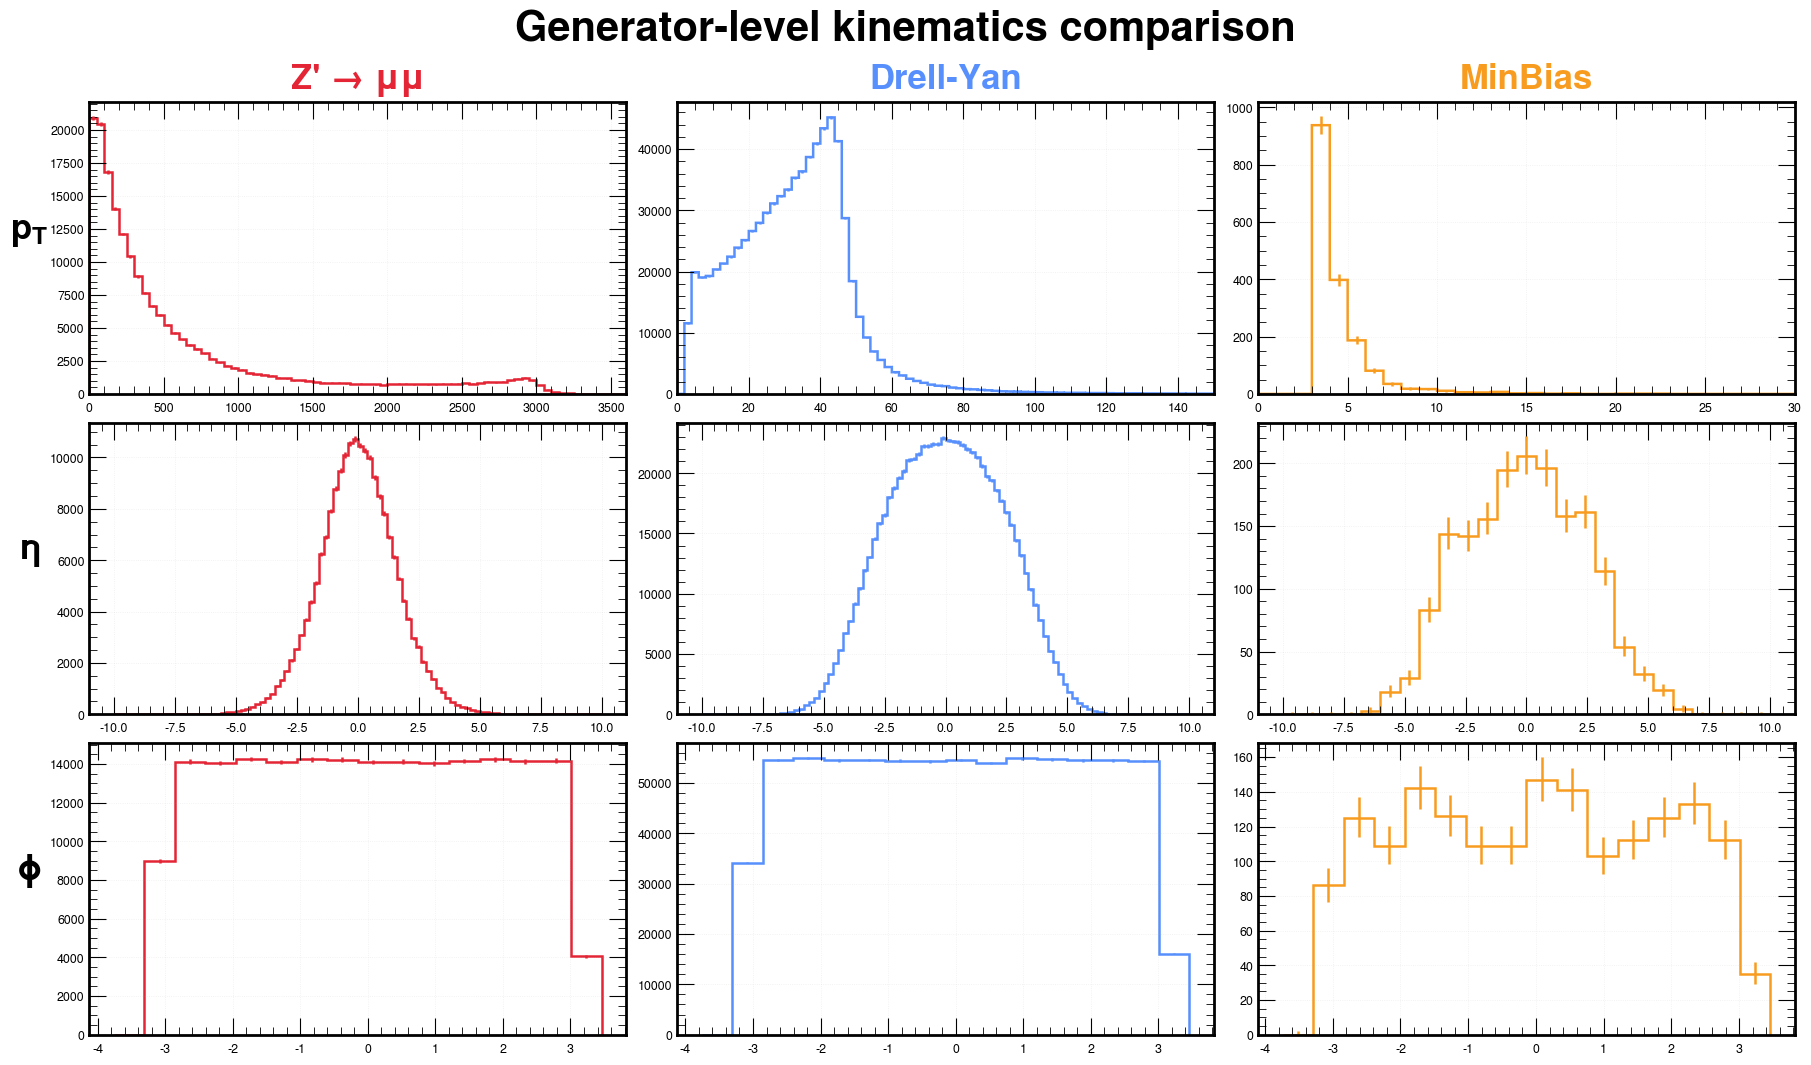

In [12]:
fig, axs = plt.subplots(3, 3, figsize=(18, 10), constrained_layout=True)
fig.patch.set_facecolor("white")

row_titles = ["$p_T$", r"$\eta$", r"$\phi$"]
col_titles = ["Z' \u2192 \u03bc\u03bc", "Drell-Yan", "MinBias"]
col_colors = [ "#e42536", "#5790fc", "#f89c20",]

axs_pt = axs[0]
axs_eta = axs[1]
axs_phi = axs[2]

for col, title in enumerate(col_titles):
    axs[0, col].set_title(title, fontsize=25, fontweight="bold", color=col_colors[col], pad=10)

for row, title in enumerate(row_titles):
    axs[row, 0].set_ylabel(title, fontsize=25, fontweight="bold", labelpad=15, rotation=0, loc="center")

plot_specs = [
    (zp_pt, 50, axs_pt[0], (0, 3600), col_colors[0]),
    (dy_pt, 2, axs_pt[1], (0, 150), col_colors[1]),
    (mb_pt, None, axs_pt[2], (0, 30), col_colors[2]),
    (zp_eta, 5, axs_eta[0], None, col_colors[0]),
    (dy_eta, 5, axs_eta[1], None, col_colors[1]),
    (mb_eta, 20, axs_eta[2], None, col_colors[2]),
    (zp_phi, 30, axs_phi[0], None, col_colors[0]),
    (dy_phi, 30, axs_phi[1], None, col_colors[1]),
    (mb_phi, 30, axs_phi[2], None, col_colors[2]),
]

for histo, rebin_factor, axis, xlim, color in plot_specs:
    plot_obj = histo if rebin_factor is None else histo[::hist.rebin(rebin_factor)]
    plot_obj.plot(ax=axis, histtype="step", color=color, linewidth=1.8)
    axis.tick_params(axis="both", labelsize=9)
    axis.grid(True, alpha=0.2, linewidth=0.6)
    axis.set_xlabel("")
    if xlim is not None:
        axis.set_xlim(*xlim)
    else:
        axis.autoscale()

fig.suptitle("Generator-level kinematics comparison", fontsize=30, fontweight="bold", y=1.05)

## Number of shower per event per sample type

In [13]:
nshowers_dy = sum([histos_dy_v1p2[key].to_hist() for key in histos_dy_v1p2.keys() if "nshowers" in key and not "noSL2" in key])
nshowers_dy = nshowers_dy * 1/dy_v1p2_nevents
nshowers_zp = sum([histos_zp_v1p2[key].to_hist() for key in histos_zp_v1p2.keys() if "nshowers" in key and not "noSL2" in key])
nshowers_zp = nshowers_zp * 1/zp_v1p2_nevents
nshowers_mb = sum([histos_mb_v1p2[key].to_hist() for key in histos_mb_v1p2.keys() if "nshowers" in key and not "noSL2" in key])
nshowers_mb = nshowers_mb * 1/mb_v1p2_nevents

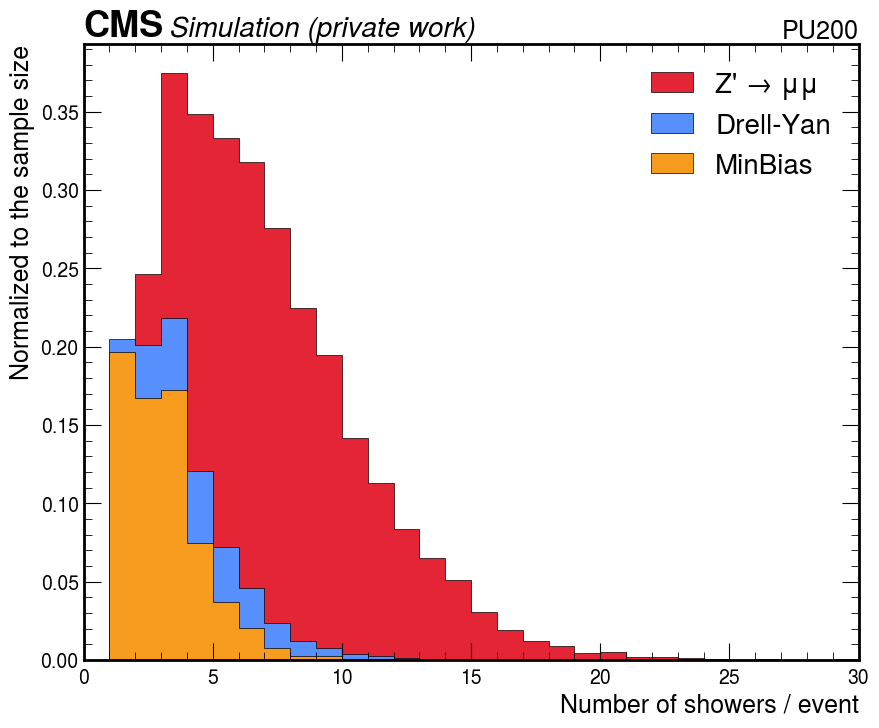

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))

nshowers_zp.plot(ax=ax, label=col_titles[0], color=col_colors[0], histtype="fill", edgecolor="black", linewidth=.5)
nshowers_dy.plot(ax=ax, label=col_titles[1], color=col_colors[1], histtype="fill", edgecolor="black", linewidth=.5)
nshowers_mb.plot(ax=ax, label=col_titles[2], color=col_colors[2], histtype="fill", edgecolor="black", linewidth=.5)
ax.set_xlim(0, 30)
ax.tick_params(axis="both", labelsize=14)
ax.set_xlabel("Number of showers / event", fontsize=18)
ax.set_ylabel("Normalized to the sample size", fontsize=18)

hep.cms.label(ax=ax, text="(private work)", data=False, rlabel="PU200", fontsize=20)
ax.legend(fontsize=20)
fig.savefig("nshowers_comparison.svg")
plt.show()

## Number of Digis per shower per sample type

In [15]:
#plot of number of shower per event per version
shower_ndigis_dy = sum([histos_dy_v1p2[key].to_hist() for key in histos_dy_v1p2.keys() if "showerNdigis" in key])
shower_ndigis_dy = shower_ndigis_dy * 1/dy_v1p2_nevents
shower_ndigis_zp = sum([histos_zp_v1p2[key].to_hist() for key in histos_zp_v1p2.keys() if "showerNdigis" in key])
shower_ndigis_zp = shower_ndigis_zp * 1/zp_v1p2_nevents
shower_ndigis_mb = sum([histos_mb_v1p2[key].to_hist() for key in histos_mb_v1p2.keys() if "showerNdigis" in key])
shower_ndigis_mb = shower_ndigis_mb * 1/mb_v1p2_nevents

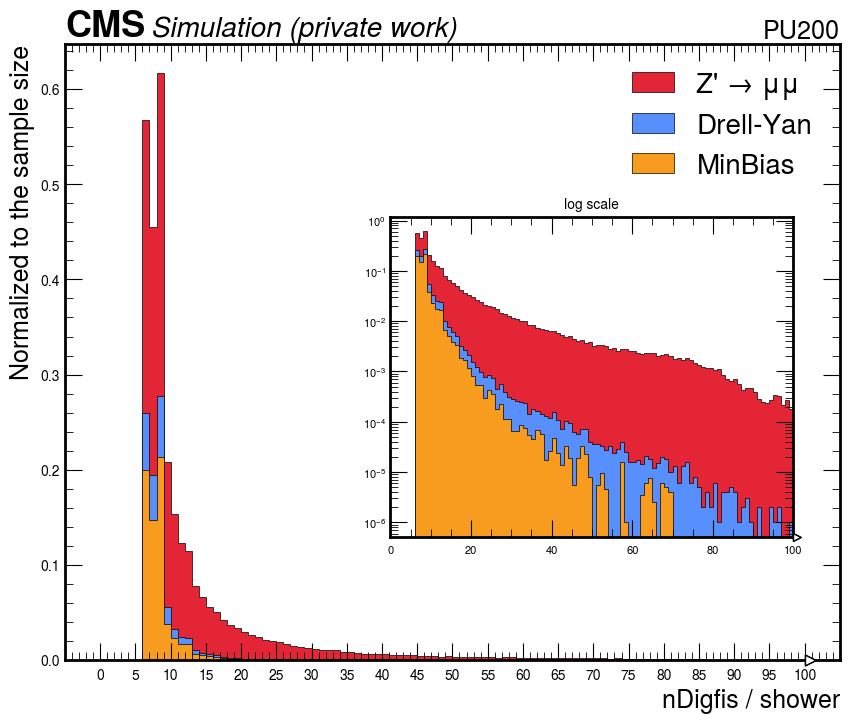

In [16]:
fig, ax = plt.subplots(figsize=(10, 8))

shower_ndigis_zp.plot(ax=ax, label=col_titles[0], color=col_colors[0], histtype="fill", edgecolor="black", linewidth=.5)
shower_ndigis_dy.plot(ax=ax, label=col_titles[1], color=col_colors[1], histtype="fill", edgecolor="black", linewidth=.5)
shower_ndigis_mb.plot(ax=ax, label=col_titles[2], color=col_colors[2], histtype="fill", edgecolor="black", linewidth=.5)
ax.set_xticks(np.arange(0, 101, 5 ))
ax.tick_params(axis="both", labelsize=10)
# ax.set_xlim(0, 85)
# ax.set_yscale("log")
ax.set_xlabel("nDigfis / shower", fontsize=18)
ax.set_ylabel("Normalized to the sample size", fontsize=18)

axins = ax.inset_axes([0.42, 0.2, 0.52, 0.52])  # [x0, y0, width, height] in axis fraction
shower_ndigis_zp.plot(ax=axins, color=col_colors[0], histtype="fill", edgecolor="black", linewidth=.5)
shower_ndigis_dy.plot(ax=axins, color=col_colors[1], histtype="fill", edgecolor="black", linewidth=.5)
shower_ndigis_mb.plot(ax=axins, color=col_colors[2], histtype="fill", edgecolor="black", linewidth=.5)
axins.set_yscale("log")
axins.set_xlim(0, 100)
axins.set_xticks(np.arange(0, 101, 20))
axins.tick_params(axis="both", labelsize=8)
axins.set_xlabel("")
axins.set_ylabel("")
axins.set_title("log scale", fontsize=10)

hep.cms.label(ax=ax, text="(private work)", data=False, rlabel="PU200", fontsize=20)
ax.legend(fontsize=20)
plt.show()

## Shower size per sample type

In [19]:
shower_size_dy = sum([histos_dy_v1p2[key].to_hist() for key in histos_dy_v1p2.keys() if "showerSize" in key])
shower_size_dy = shower_size_dy * 1/dy_v1p2_nevents
shower_size_zp = sum([histos_zp_v1p2[key].to_hist() for key in histos_zp_v1p2.keys() if "showerSize" in key])
shower_size_zp = shower_size_zp * 1/zp_v1p2_nevents
shower_size_mb = sum([histos_mb_v1p2[key].to_hist() for key in histos_mb_v1p2.keys() if "showerSize" in key])
shower_size_mb = shower_size_mb * 1/mb_v1p2_nevents

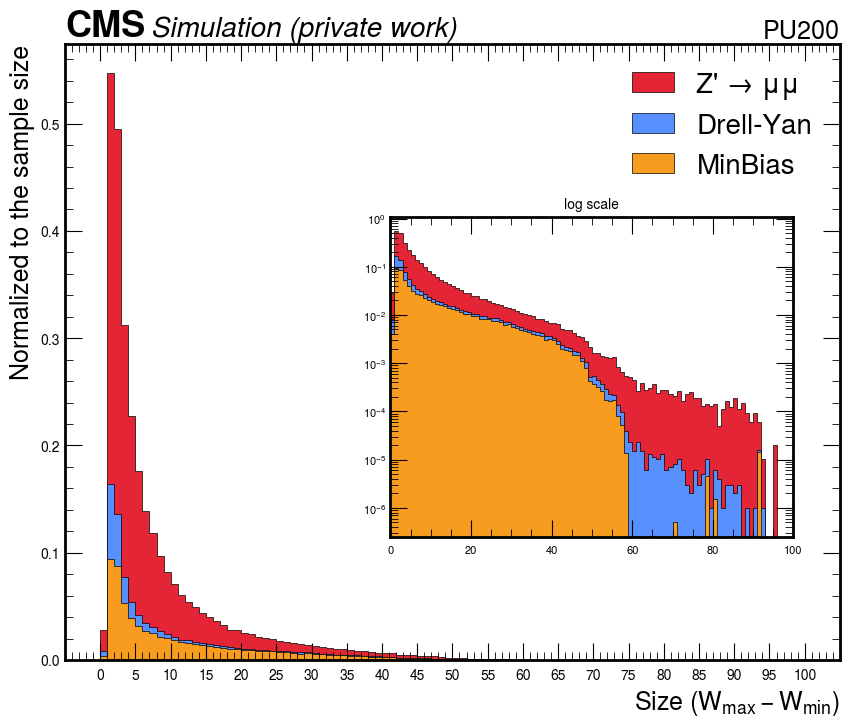

In [20]:
fig, ax = plt.subplots(figsize=(10, 8))

shower_size_zp.plot(ax=ax, label=col_titles[0], color=col_colors[0], histtype="fill", edgecolor="black", linewidth=.5)
shower_size_dy.plot(ax=ax, label=col_titles[1], color=col_colors[1], histtype="fill", edgecolor="black", linewidth=.5)
shower_size_mb.plot(ax=ax, label=col_titles[2], color=col_colors[2], histtype="fill", edgecolor="black", linewidth=.5)
ax.set_xticks(np.arange(0, 101, 5 ))
ax.tick_params(axis="both", labelsize=10)
# ax.set_xlim(0, 85)
ax.set_xlabel("Size ($W_{max} - W_{min})$", fontsize=18)
ax.set_ylabel("Normalized to the sample size", fontsize=18)

axins = ax.inset_axes([0.42, 0.2, 0.52, 0.52])  # [x0, y0, width, height] in axis fraction
shower_size_zp.plot(ax=axins, color=col_colors[0], histtype="fill", edgecolor="black", linewidth=.5)
shower_size_dy.plot(ax=axins, color=col_colors[1], histtype="fill", edgecolor="black", linewidth=.5)
shower_size_mb.plot(ax=axins, color=col_colors[2], histtype="fill", edgecolor="black", linewidth=.5)
axins.set_yscale("log")
axins.set_xlim(0, 100)
axins.set_xticks(np.arange(0, 101, 20))
axins.tick_params(axis="both", labelsize=8)
axins.set_xlabel("")
axins.set_ylabel("")
axins.set_title("log scale", fontsize=10)

hep.cms.label(ax=ax, text="(private work)", data=False, rlabel="PU200", fontsize=20)
ax.legend(fontsize=20)
plt.show()